point cloud data is stored as a 2D matrix  
each row has 3 values i.e. the x, y, z value for a point

Project has to be submitted to github in the private folder assigned to you.  
Readme file should have the numerical values as described in each task.  
Create a folder to store the images as described in the tasks.

Try to create commits and version for each task.

In [57]:
import matplotlib
import numpy as np
from pathlib import Path
from scipy.spatial import KDTree
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# utility functions
def show_cloud(points_plt, title=None):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(points_plt[:,0], points_plt[:,1], points_plt[:,2], s=0.05)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    if title:
        ax.set_title(title)
    plt.show()

def show_scatter(x, y, title=None):
    plt.scatter(x, y)
    if title:
        plt.title(title)
    plt.show()


In [59]:
# read files containing point cloud data
datasets = {
    'dataset1': np.load('dataset1.npy'),
    'dataset2': np.load('dataset2.npy'),
}

# Keep dataset1 selected for the starter cells below.
pcd = datasets['dataset1']

{name: data.shape for name, data in datasets.items()}

{'dataset1': (72067, 3), 'dataset2': (84588, 3)}

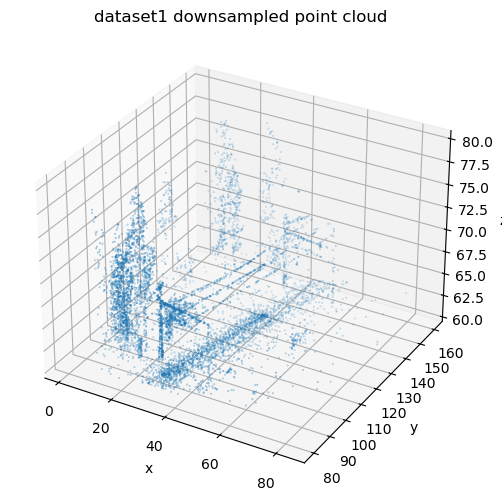

In [60]:
# show downsampled data
%matplotlib inline
show_cloud(pcd[::10], title='dataset1 downsampled point cloud') # keep every 10th point

## Task 1 (3)

### Idea

I use a histogram of the `z` values to find where the ground is. The ground should give the biggest peak, since many LiDAR points are reflected from the ground. I find that peak first, but I use the next bin as the cutoff so a bit more of the ground is removed before clustering.

The histograms for both datasets have a clear peak at about the same height. With the next-bin cutoff I get `61.442` for dataset 1 and `61.466` for dataset 2. These values are a little higher than the peak itself, but that should make the point cloud above ground cleaner.

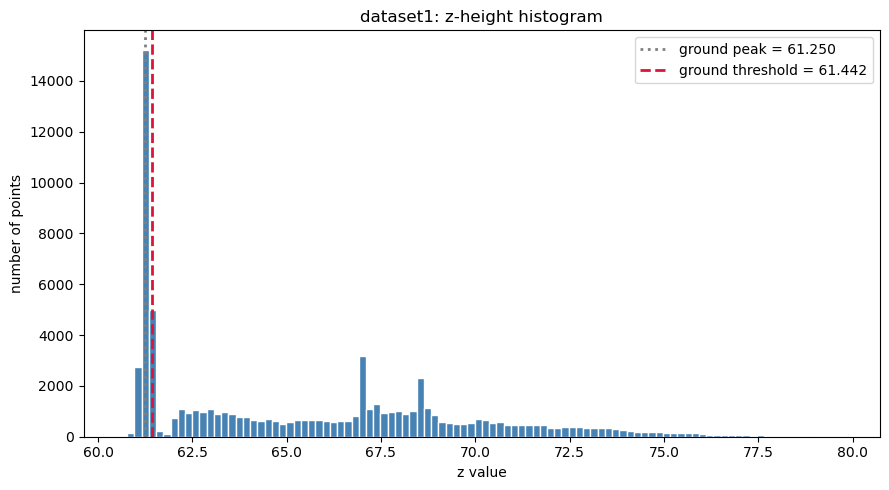

dataset1: ground level = 61.442


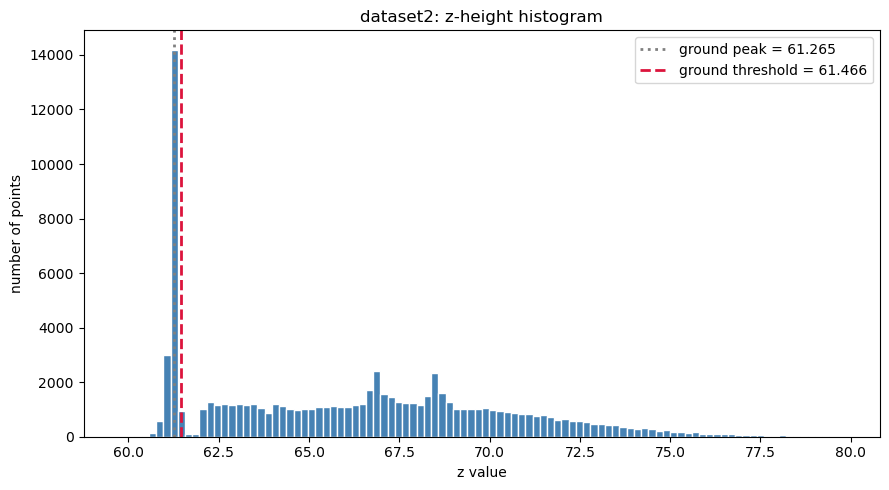

dataset2: ground level = 61.466


In [71]:
# Task 1: estimate ground level for both datasets using z-height histograms.
def get_ground_level(pcd, bins=100):
    z_values = pcd[:, 2]
    counts, bin_edges = np.histogram(z_values, bins=bins)
    ground_bin = np.argmax(counts)
    threshold_bin = min(ground_bin + 1, len(counts) - 1)
    ground_level = (bin_edges[threshold_bin] + bin_edges[threshold_bin + 1]) / 2
    return ground_level

def plot_ground_histogram(pcd, dataset_name, bins=100):
    z_values = pcd[:, 2]
    counts, bin_edges = np.histogram(z_values, bins=bins)
    ground_bin = np.argmax(counts)
    threshold_bin = min(ground_bin + 1, len(counts) - 1)
    ground_peak_level = (bin_edges[ground_bin] + bin_edges[ground_bin + 1]) / 2
    ground_level = (bin_edges[threshold_bin] + bin_edges[threshold_bin + 1]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    Path('images').mkdir(exist_ok=True)

    plt.figure(figsize=(9, 5))
    plt.bar(bin_edges[:-1], counts, width=bin_width, align='edge', color='steelblue', edgecolor='white')
    plt.axvline(ground_peak_level, color='yellow', linestyle=':', linewidth=2, label=f'ground peak = {ground_peak_level:.3f}')
    plt.axvline(ground_level, color='crimson', linestyle='--', linewidth=2, label=f'ground threshold = {ground_level:.3f}')
    plt.title(f'{dataset_name}: z-height histogram')
    plt.xlabel('z value')
    plt.ylabel('number of points')
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_ground_histogram.png', dpi=200)
    plt.show()

    return ground_level

ground_levels = {}
pcd_above_ground_by_dataset = {}

for dataset_name, data in datasets.items():
    ground_level = plot_ground_histogram(data, dataset_name, bins=100)
    ground_levels[dataset_name] = ground_level
    pcd_above_ground_by_dataset[dataset_name] = data[data[:, 2] > ground_level]
    print(f'{dataset_name}: ground level = {ground_level:.3f}')

# Keep dataset1 selected for the starter cells below.
est_ground_level = ground_levels['dataset1']
pcd_above_ground = pcd_above_ground_by_dataset['dataset1']

In [ ]:
{name: points.shape for name, points in pcd_above_ground_by_dataset.items()} 
# Number of points left after removing the ground.

{'dataset1': (49762, 3), 'dataset2': (65894, 3)}

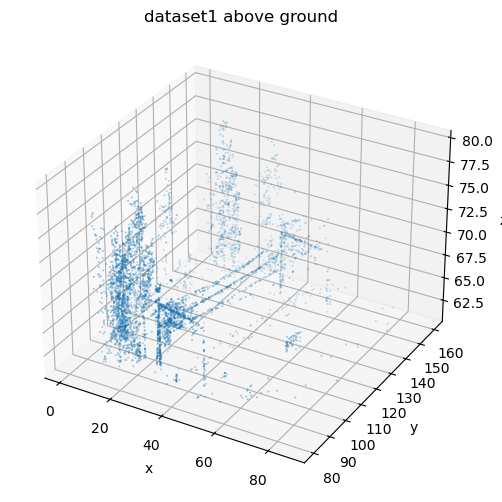

In [ ]:
# side view
show_cloud(pcd_above_ground[::10], title='dataset1 above ground')

Dataset 1 looks cleaner after removing the ground points. Most of the flat ground area is gone, so the remaining structures are easier to see.

## Task 2 (+1)
In this part, the points that are left after removing the ground are clustered. This allows to identify different structures or patterns. 

DBSCAN works by looking for dense areas. `eps` is the search distance around each point, and `min_samples` is how many nearby points are needed for a point to count as a core point. Points that are not close enough to a dense area are marked as noise with label `-1`. This is useful here because we do not know the number of clusters before running the algorithm.

To choose `eps`, we analyze the k-distance elbow plot. We choose the a suiting point where the curve starts rising quickly (elbow). If `eps` is too small, one real object can split into many small clusters. If it is too large, separate objects can merge. Here `eps = 1.000` is chosen. This makes the main structures visible, but some some small clusters and noise points still appear, especially in dataset 2.

References: [Analytics Vidhya DBSCAN explanation](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/) and [Machine Learning Knowledge DBSCAN tutorial](https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/).

In [ ]:
#Helper function to plot the k-distance elbow plot for DBSCAN eps selection.
def plot_eps_elbow(points, dataset_name, selected_eps, min_samples=5):
    tree = KDTree(points)
    distances, _ = tree.query(points, k=min_samples)
    k_distances = np.sort(distances[:, -1])

    Path('images').mkdir(exist_ok=True)
    eps_idx = np.searchsorted(k_distances, selected_eps)
    eps_idx = min(eps_idx, len(k_distances) - 1)

    plt.figure(figsize=(9, 5))
    plt.plot(k_distances, linewidth=1.5)
    plt.axhline(selected_eps, color='crimson', linestyle='--', linewidth=2, label=f'selected eps = {selected_eps:.3f}')
    plt.scatter(eps_idx, k_distances[eps_idx], color='crimson', s=45)
    plt.title(f'{dataset_name}: DBSCAN k-distance elbow plot')
    plt.xlabel('points sorted by distance')
    plt.ylabel(f'distance to {min_samples}th nearest neighbor')
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_dbscan_elbow.png', dpi=200)
    plt.show()

    return k_distances

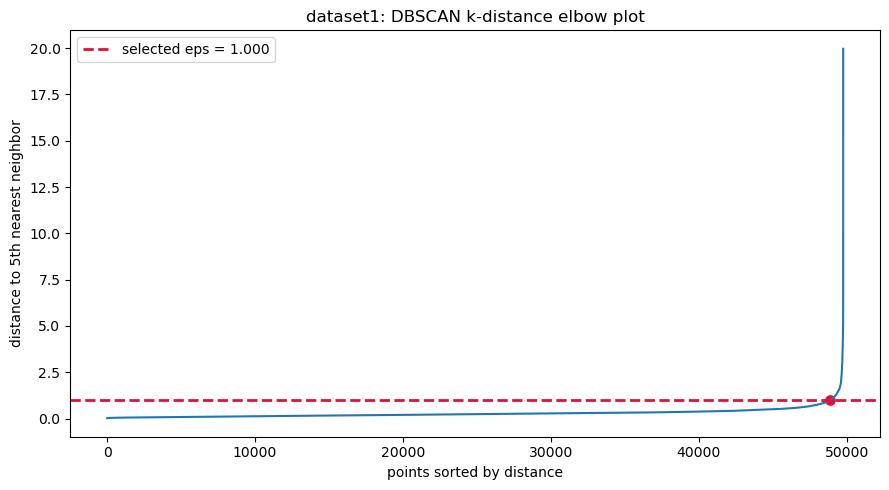

dataset1: selected eps = 1.000


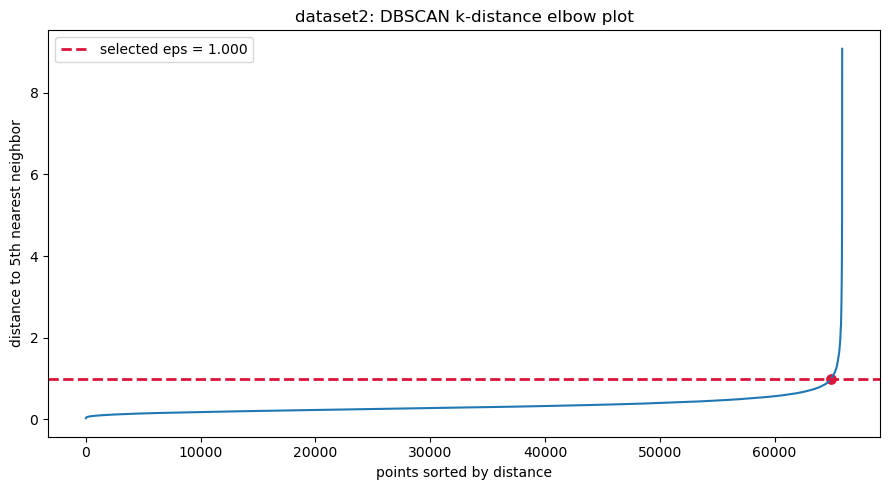

dataset2: selected eps = 1.000


{'dataset1': 1.0, 'dataset2': 1.0}

In [78]:
min_samples = 5

# Chosen from the elbow plots: this is near the beginning of the sharp upward bend.
eps_values = {
    'dataset1': 1.0,
    'dataset2': 1.0,
}

k_distances_by_dataset = {}

for dataset_name, points in pcd_above_ground_by_dataset.items():
    k_distances = plot_eps_elbow(points, dataset_name, selected_eps=eps_values[dataset_name], min_samples=min_samples)
    k_distances_by_dataset[dataset_name] = k_distances
    print(f'{dataset_name}: selected eps = {eps_values[dataset_name]:.3f}')

eps_values

In [ ]:
#This is DBscan helper function to plot the clusters and save the image.
def plot_dbscan_clusters(points, labels, dataset_name, eps):
    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    Path('images').mkdir(exist_ok=True)

    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab20', s=2)
    plt.title(f'{dataset_name}: DBSCAN clusters, eps={eps:.3f}, clusters={clusters}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_dbscan_clusters.png', dpi=200)
    plt.show()

    return clusters

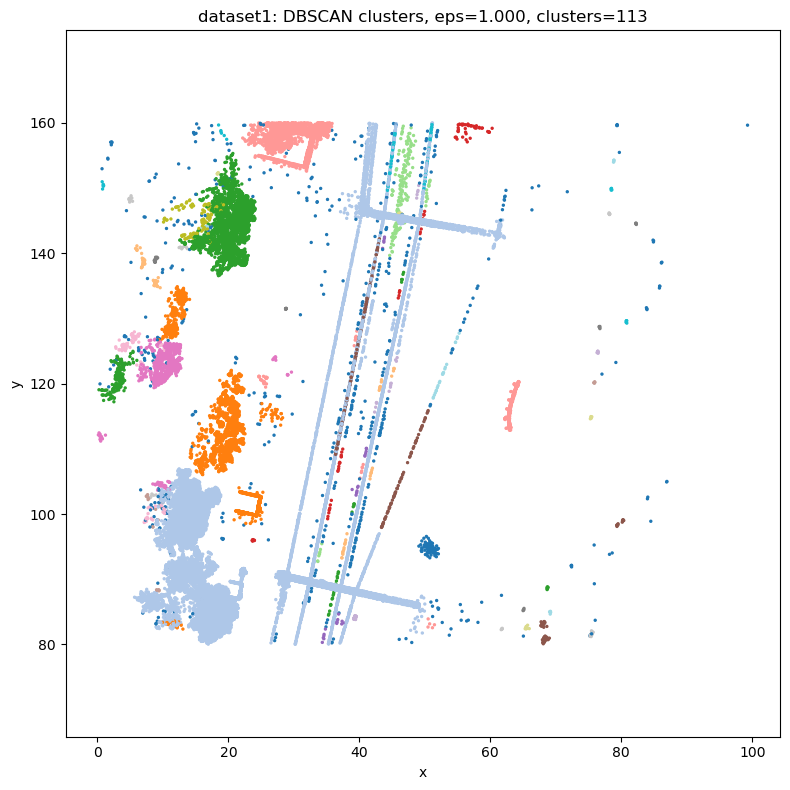

dataset1: eps = 1.000, clusters = 113, noise points = 542


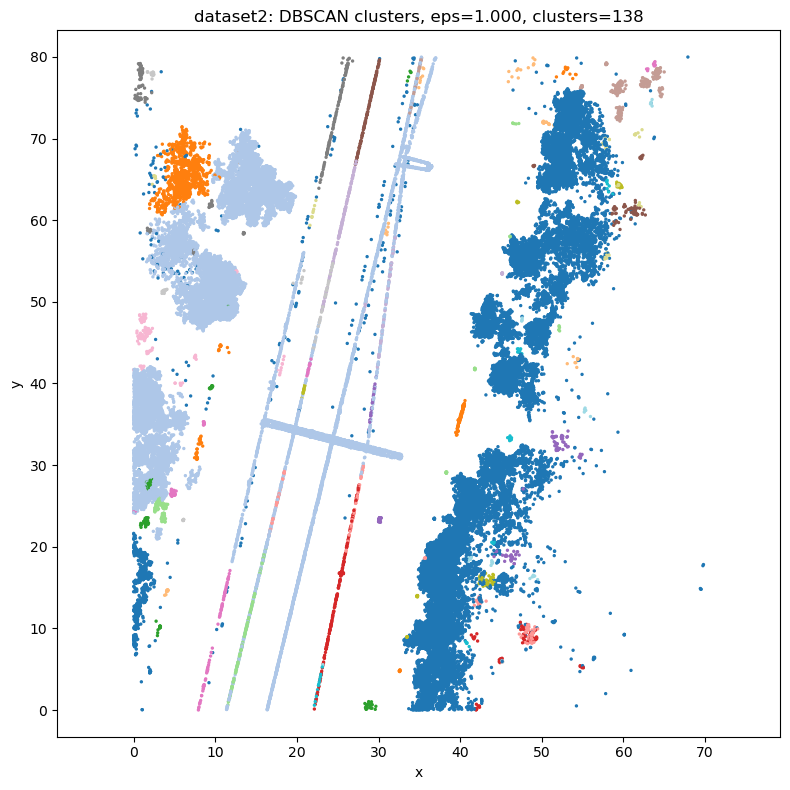

dataset2: eps = 1.000, clusters = 138, noise points = 565


In [ ]:
# Run DBSCAN clustering and plot results for each dataset.
dbscan_results = {}
cluster_counts = {}

for dataset_name, points in pcd_above_ground_by_dataset.items():
    eps = eps_values[dataset_name]
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_
    dbscan_results[dataset_name] = clustering
    cluster_counts[dataset_name] = plot_dbscan_clusters(points, labels, dataset_name, eps)
    noise_points = np.sum(labels == -1)
    print(f'{dataset_name}: eps = {eps:.3f}, clusters = {cluster_counts[dataset_name]}, noise points = {noise_points}')

See the readme file for further analysis